# Titanic Survival Prediction: Comprehensive ML Modelling
## Random Forest | XGBoost | Gradient Boosting
Author: Stewie-pixel

Dataset: Titanic Survival Prediction

Goal: Predict who will survive and who will die using the Titanic passenger data.

## Introduction

The Titanic disaster of 1912 is one of the most well-known tragedies in history.
Of the 2,224 passengers and crew aboard, more than 1,500 died — largely due to
an insufficient number of lifeboats and the chaotic evacuation process.

This notebook builds a machine learning pipeline to predict passenger survival
using structured data. Rather than relying on a single model, we engineer meaningful features and combine
three powerful classifiers into a Voting Ensemble to maximise predictive accuracy.

## Table of Contents

1. [Import Libraries](#1.-Import-Libraries)
2. [Data Overview](#2.-Data-Overview)
3. [Exploratory Data Analysis](#3.-Exploratory-Data-Analysis)
   - 3.1 [Survival Distribution](#3.1-Survival-Distribution)
   - 3.2 [Numerical Features Analysis](#3.2-Numerical-Features-Analysis)
   - 3.3 [Categorical Features Analysis](#3.3-Categorical-Features-Analysis)
   - 3.4 [Correlation & Feature Relationships](#3.4-Correlation-&-Feature-Relationships)
4. [Data Preprocessing](#4.-Data-Preprocessing)
5. [Feature Engineering](#5.-Feature-Engineering)
6. [Modelling](#6.-Modelling)
   - 6.1 [Random Forest](#6.1-Random-Forest)
   - 6.2 [Gradient Boosting](#6.2-Gradient-Boosting)
   - 6.3 [XGBoost](#6.3-XGBoost)
   - 6.4 [Model Performance Comparison](#6.4-Model-Performance-Comparison)
7. [Voting Ensemble](#7.-Voting-Ensemble)
8. [Save Pipeline Artifacts](#8.-Save-Pipeline-Artifacts)
9. [Conclusion](#9.-Conclusion)

## 1. Import Libraries
Import all required libraries and load the Titanic dataset.

In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pickle
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.metrics import (accuracy_score, log_loss)
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from xgboost import XGBClassifier

print("All libraries imported successfully.")

All libraries imported successfully.


In [16]:
# Color palette and plot settings
plt.rcParams.update({
    'figure.facecolor':  '#FAFAFA',
    'axes.facecolor':    '#F5F5F5',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'font.family':       'DejaVu Sans',
    'font.size':         11,
})

PALETTE  = ['#2E86AB', '#A23B72', '#F18F01', '#C73E1D', '#3B1F2B']
SURVIVED = ["#FF0000", '#2E86AB']

#### Now we load the necessary datas

In [4]:
train = pd.read_csv('../data/train.csv')
test = pd.read_csv('../data/test.csv')

print("Data loaded successfully.")
print("Training data shape:", train.shape)
print("Testing data shape:", test.shape)

train.head()

Data loaded successfully.
Training data shape: (891, 12)
Testing data shape: (418, 11)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


## 2. Data Overview
Examine the dataset structure, data types, missing values, and basic statistics.

In [5]:
train.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [6]:
print("Missing values in dataset:")

missing_values = train.isnull().sum()
missing_percentage = (missing_values / len(train)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print(missing_df[missing_df['Missing Values'] > 0])

Missing values in dataset:
          Missing Values  Percentage
Age                  177   19.865320
Cabin                687   77.104377
Embarked               2    0.224467


In [7]:
train.describe().round(2)

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


## 3. Exploratory Data Analysis
Visualise patterns in the data to understand which features influence survival.

### 3.1 Survival Distribution

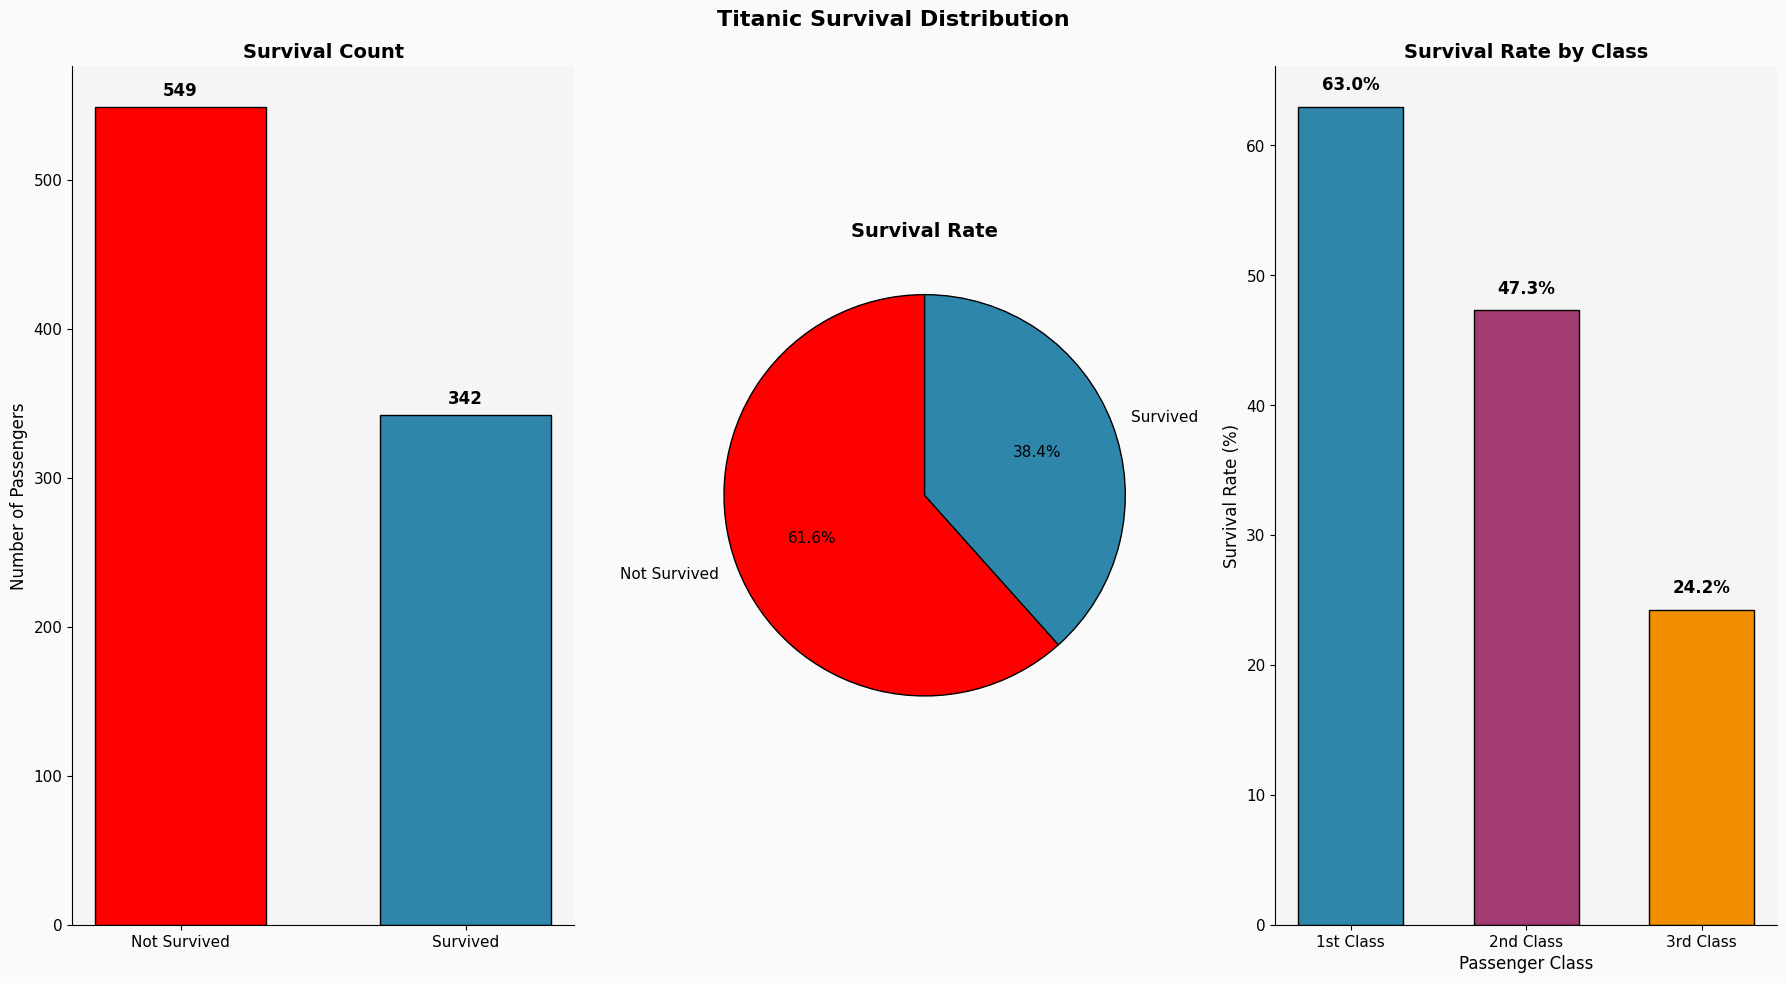

Overall Survival Rate: 38.38%


In [17]:
fig, axes = plt.subplots(1, 3, figsize=(18, 10), squeeze=True)
fig.suptitle('Titanic Survival Distribution', fontsize=16, fontweight='bold')

# Count plot
counts = train['Survived'].value_counts()
bars = axes[0].bar(['Not Survived', 'Survived'], counts.values, color=SURVIVED, width=0.6, edgecolor='black')

for bar, val in zip(bars, counts.values):
    axes[0].text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5, str(val), ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0].set_title('Survival Count', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Number of Passengers', fontsize=12)

# Pie Chart
axes[1].pie(counts.values, labels=['Not Survived', 'Survived'], autopct='%1.1f%%', colors=SURVIVED, startangle=90, wedgeprops={'edgecolor': 'black'})
axes[1].set_title('Survival Rate', fontsize=14, fontweight='bold')

# Survival Rate by Class
survival_by_class = train.groupby('Pclass')['Survived'].mean() * 100
axes[2].bar(survival_by_class.index, survival_by_class.values, color=PALETTE[:3], width=0.6, edgecolor='black')

for idx, val in survival_by_class.items():
    axes[2].text(idx, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[2].set_title('Survival Rate by Class', fontsize=14, fontweight='bold')
axes[2].set_xlabel('Passenger Class', fontsize=12)
axes[2].set_ylabel('Survival Rate (%)', fontsize=12)
axes[2].set_xticks([1, 2, 3])
axes[2].set_xticklabels(['1st Class', '2nd Class', '3rd Class'])

plt.tight_layout()
plt.show()

print(f"Overall Survival Rate: {train['Survived'].mean() * 100:.2f}%")

### 3.2 Numerical Features Analysis

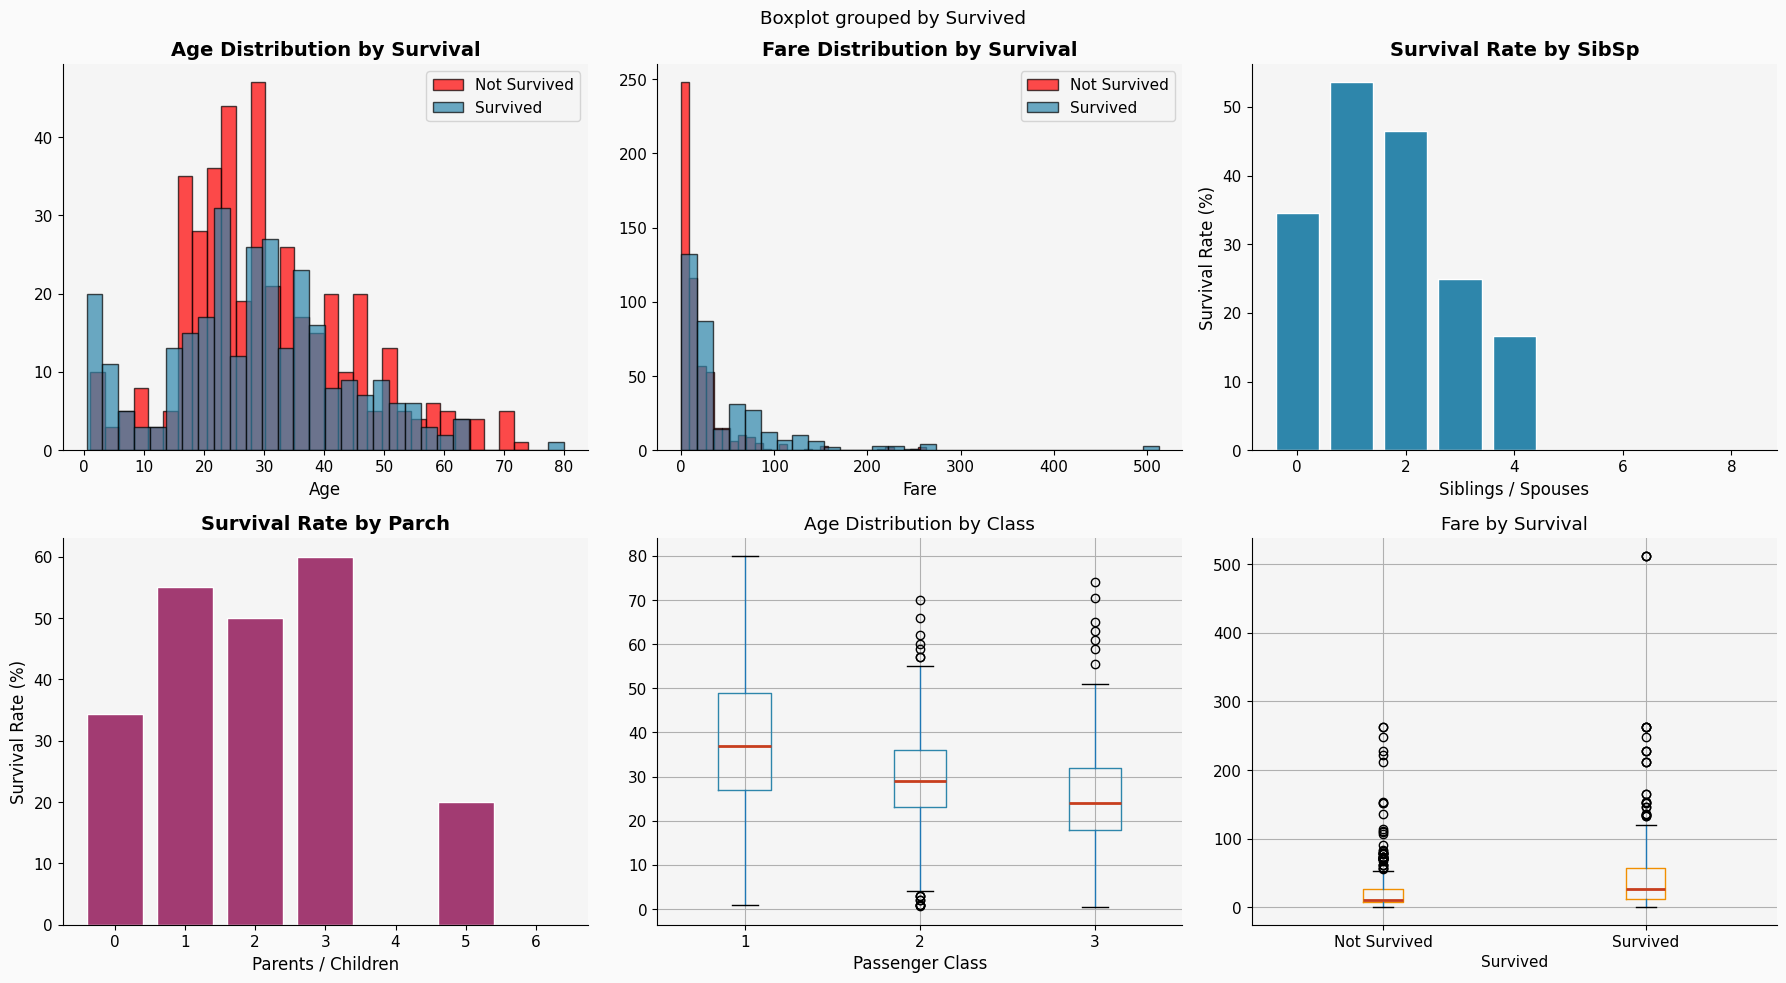

In [18]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Numerical Feature Analysis', fontsize=16, fontweight='bold')

# Age Distribution by Survival
for survived, label, color in zip([0, 1], ['Not Survived', 'Survived'], SURVIVED):
    subset = train[train['Survived'] == survived]['Age'].dropna()
    axes[0, 0].hist(subset, bins=30, alpha=0.7, label=label, color=color, edgecolor='black')
axes[0, 0].set_title('Age Distribution by Survival', fontsize=14, fontweight='bold')
axes[0, 0].set_xlabel('Age', fontsize=12)
axes[0, 0].legend()

# Fare Distribution by Survival
for survived, label, color in zip([0, 1], ['Not Survived', 'Survived'], SURVIVED):
    subset = train[train['Survived'] == survived]['Fare'].dropna()
    axes[0, 1].hist(subset, bins=30, alpha=0.7, label=label, color=color, edgecolor='black')
axes[0, 1].set_title('Fare Distribution by Survival', fontsize=14, fontweight='bold')
axes[0, 1].set_xlabel('Fare', fontsize=12)
axes[0, 1].legend()

# SibSp survival rate
sibsp_surv = train.groupby('SibSp')['Survived'].mean() * 100
axes[0, 2].bar(sibsp_surv.index, sibsp_surv.values,
               color=PALETTE[0], edgecolor='white')
axes[0, 2].set_title('Survival Rate by SibSp', fontsize=14, fontweight='bold')
axes[0, 2].set_xlabel('Siblings / Spouses', fontsize=12)
axes[0, 2].set_ylabel('Survival Rate (%)', fontsize=12)

# Parch survival rate
parch_surv = train.groupby('Parch')['Survived'].mean() * 100
axes[1, 0].bar(parch_surv.index, parch_surv.values,
               color=PALETTE[1], edgecolor='white')
axes[1, 0].set_title('Survival Rate by Parch', fontsize=14, fontweight='bold')
axes[1, 0].set_xlabel('Parents / Children', fontsize=12)
axes[1, 0].set_ylabel('Survival Rate (%)', fontsize=12)

# Age box plot by class
train.boxplot(column='Age', by='Pclass', ax=axes[1, 1],
              boxprops=dict(color=PALETTE[0]),
              medianprops=dict(color=PALETTE[3], linewidth=2))
axes[1, 1].set_title('Age Distribution by Class', fontsize=14, fontweight='bold')
axes[1, 1].set_xlabel('Passenger Class', fontsize=12)
plt.sca(axes[1, 1])
plt.title('Age Distribution by Class')

# Fare box plot by survival
train.boxplot(column='Fare', by='Survived', ax=axes[1, 2],
              boxprops=dict(color=PALETTE[2]),
              medianprops=dict(color=PALETTE[3], linewidth=2))
axes[1, 2].set_title('Fare by Survival', fontsize=14, fontweight='bold')
axes[1, 2].set_xticklabels(['Not Survived', 'Survived'])
plt.sca(axes[1, 2])
plt.title('Fare by Survival')

plt.tight_layout()
plt.show()

### 3.3 Categorical Features Analysis

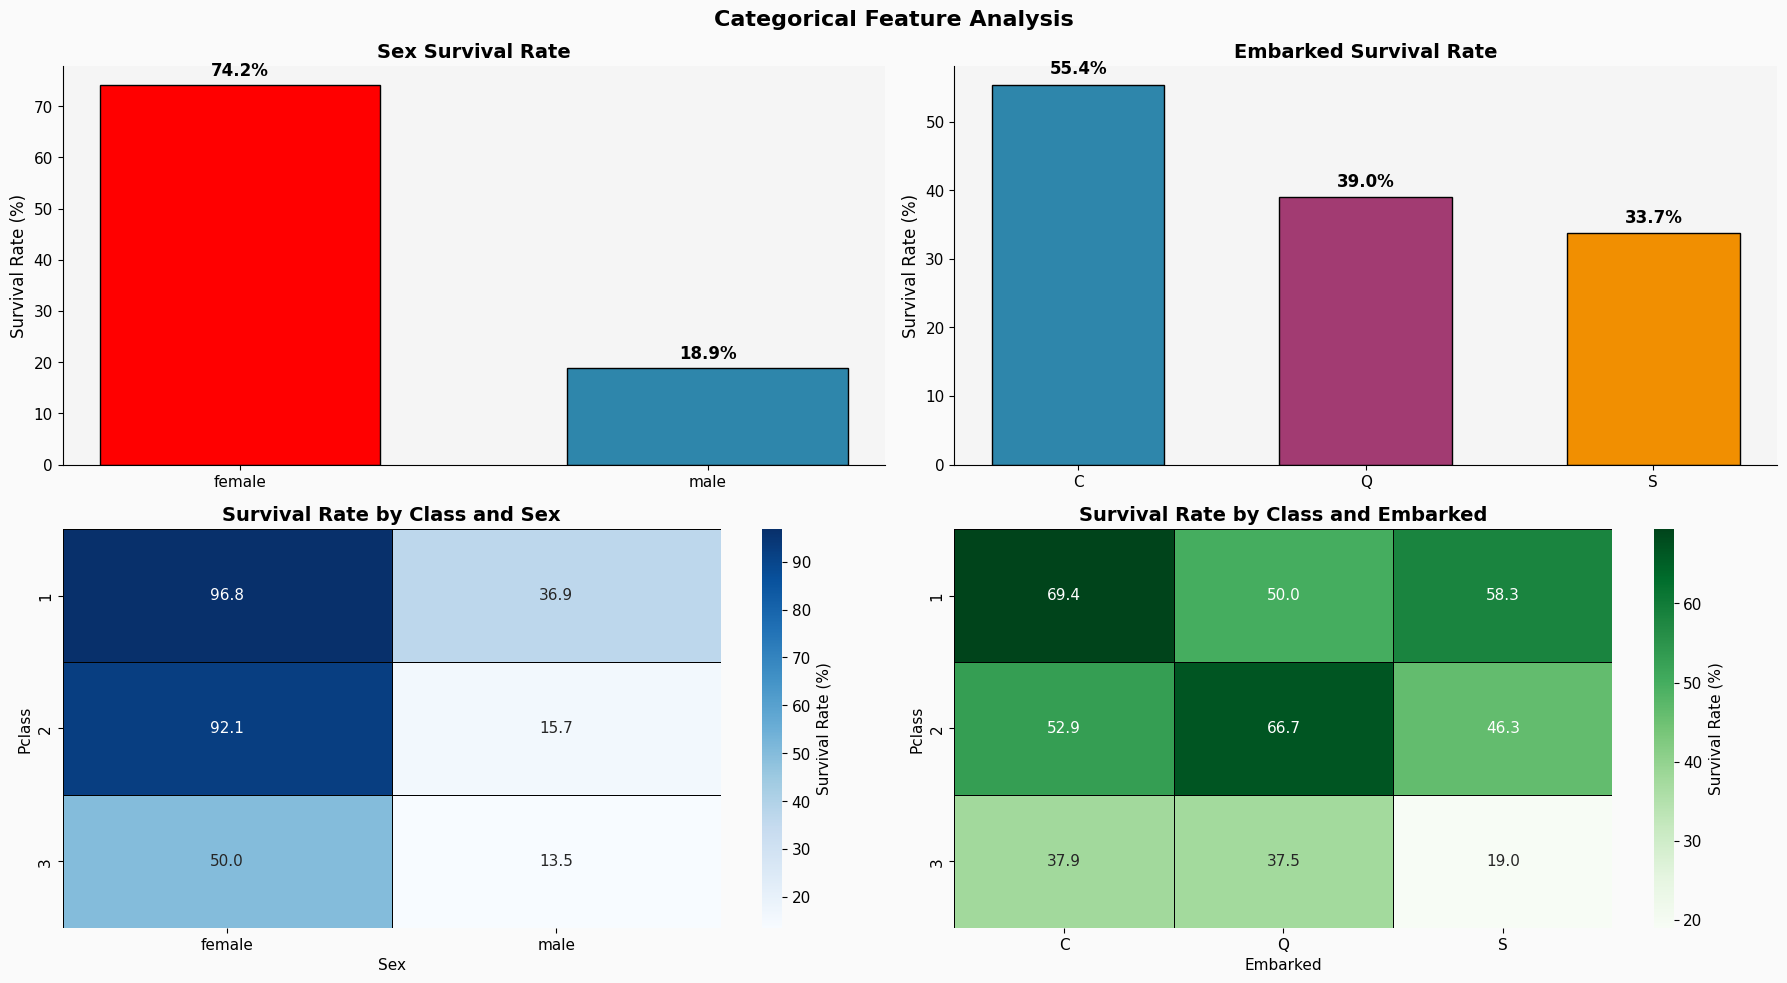

In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 10))
fig.suptitle('Categorical Feature Analysis', fontsize=16, fontweight='bold')

# Sex survival rate
sex_survival = train.groupby('Sex')['Survived'].mean() * 100
axes[0, 0].bar(range(len(sex_survival)), sex_survival.values, color=[SURVIVED[0], SURVIVED[1]], edgecolor='black', width=0.6)
axes[0, 0].set_xticks(range(len(sex_survival)))
axes[0, 0].set_xticklabels(sex_survival.index)

for idx, val in enumerate(sex_survival.values):
    axes[0, 0].text(idx, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Sex Survival Rate', fontsize=14, fontweight='bold')
axes[0, 0].set_ylabel('Survival Rate (%)', fontsize=12)

# Embarked survival rate
embarked_survival = train.groupby('Embarked')['Survived'].mean() * 100
axes[0, 1].bar(range(len(embarked_survival)), embarked_survival.values, color=PALETTE[:3], edgecolor='black', width=0.6)
axes[0, 1].set_xticks(range(len(embarked_survival)))
axes[0, 1].set_xticklabels(embarked_survival.index)

for idx, val in enumerate(embarked_survival.values):
    axes[0, 1].text(idx, val + 1, f'{val:.1f}%', ha='center', va='bottom', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Embarked Survival Rate', fontsize=14, fontweight='bold')
axes[0, 1].set_ylabel('Survival Rate (%)', fontsize=12)

# Class x Sex heatmap
pivot1 = train.pivot_table(values='Survived', index='Pclass', columns='Sex', aggfunc='mean') * 100
sns.heatmap(pivot1, annot=True, fmt='.1f', cmap='Blues', ax=axes[1, 0], cbar_kws={'label': 'Survival Rate (%)'}, linewidths=0.5, linecolor='black')
axes[1, 0].set_title('Survival Rate by Class and Sex', fontsize=14, fontweight='bold')

# Class x Embarked heatmap
pivot2 = train.pivot_table(values='Survived', index='Pclass', columns='Embarked', aggfunc='mean') * 100
sns.heatmap(pivot2, annot=True, fmt='.1f', cmap='Greens', ax=axes[1, 1], cbar_kws={'label': 'Survival Rate (%)'}, linewidths=0.5, linecolor='black')
axes[1, 1].set_title('Survival Rate by Class and Embarked', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

### 3.4 Correlation & Feature Relationships

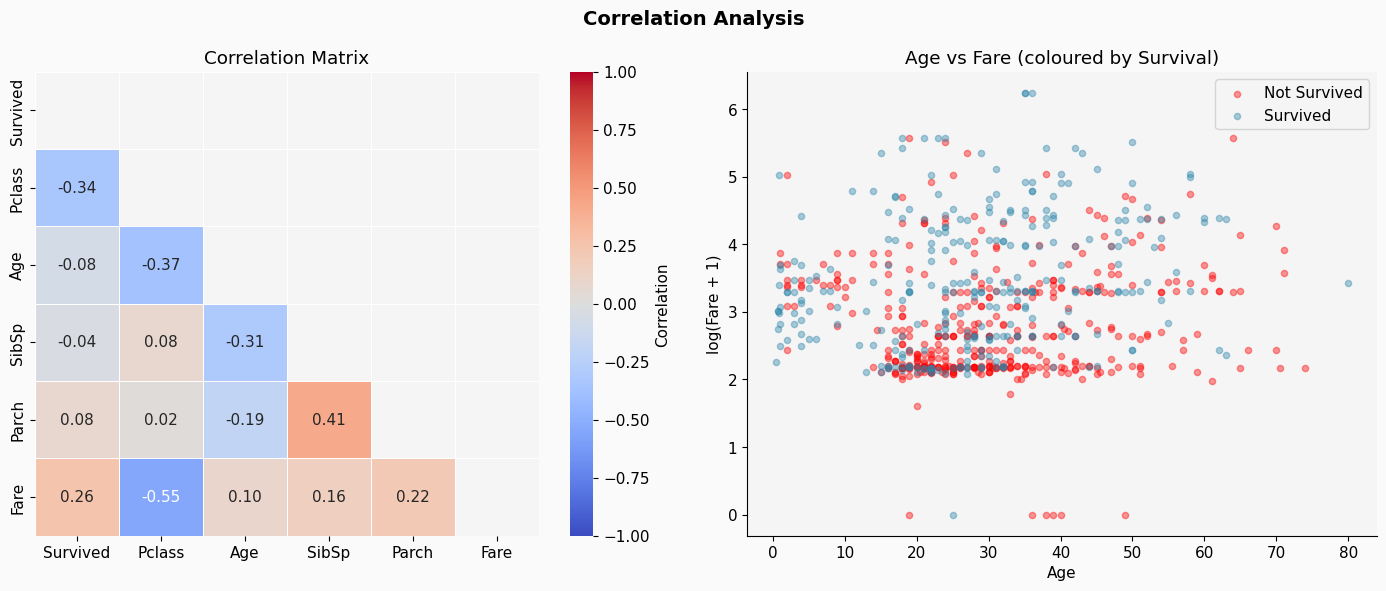

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Correlation Analysis', fontsize=14, fontweight='bold')

# Correlation heatmap
num_cols = ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
corr = train[num_cols].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', ax=axes[0], linewidths=0.5,
            vmin=-1, vmax=1, cbar_kws={'label': 'Correlation'})
axes[0].set_title('Correlation Matrix')

# Age vs Fare scatter coloured by survival
for survived, label, color in zip([0, 1], ['Not Survived', 'Survived'], SURVIVED):
    subset = train[train['Survived'] == survived]
    axes[1].scatter(subset['Age'], np.log1p(subset['Fare']),
                    alpha=0.4, s=20, color=color, label=label)
axes[1].set_xlabel('Age')
axes[1].set_ylabel('log(Fare + 1)')
axes[1].set_title('Age vs Fare (coloured by Survival)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 4. Data Preprocessing & Cleaning
Handle missing values and drop low-signal columns before feature engineering.

In [21]:
def clean_data(df):
    df = df.copy()

    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    df = df.drop(columns=['Ticket'], errors='ignore')

    return df

train = clean_data(train)
test = clean_data(test)

print("Missing values after cleaning:")
print(train.isnull().sum()[train.isnull().sum() > 0])
print(f"\nTrain shape after cleaning: {train.shape}")

Missing values after cleaning:
Age      177
Cabin    687
dtype: int64

Train shape after cleaning: (891, 11)


## 5. Feature Engineering
Test the new features using cross-validation to see if they made a difference

In [25]:
def feature_engineering(df):
    df = df.copy()

    df['Title'] = df['Name'].str.extract(r' ([A-Za-z]+)\.', expand=False)
    df['Title'] = df['Title'].replace(['Lady', 'Countess', 'Capt', 'Col', 'Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona'], 'Rare')
    df['Title'] = df['Title'].replace({'Mlle': 'Miss', 'Ms': 'Miss', 'Mme': 'Mrs'})

    df['FamilySize'] = df['SibSp'] + df['Parch'] + 1
    df['IsAlone'] = df['FamilySize'].apply(lambda x: 1 if x == 1 else 0).astype(int)

    df['CabinDeck'] = df['Cabin'].str[0].fillna('Unknown')

    age_median = df.groupby('Title')['Age'].transform('median')
    df['Age'] = df['Age'].fillna(age_median).fillna(df['Age'].median())
    df['AgeBand'] = pd.cut(df['Age'], bins=[0, 12, 18, 35, 60, 100], labels=['Child', 'Teen', 'Adult', 'MidAge', 'Senior'])

    df['Fare'] = df['Fare'].fillna(df['Fare'].median())
    df['FareBand'] = pd.qcut(df['Fare'], q=4, labels=['Low', 'Medium', 'High', 'Very High'])
    
    df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

    return df

train = feature_engineering(train)
test = feature_engineering(test)
print("Feature engineering completed.")
train[['Title','FamilySize','IsAlone','CabinDeck','AgeBand','FareBand']].head()

Feature engineering completed.


,Title,FamilySize,IsAlone,CabinDeck,AgeBand,FareBand
0,Mr,2,0,Unknown,Adult,Low
1,Mrs,2,0,C,MidAge,Very High
2,Miss,1,1,Unknown,Adult,Medium
3,Mrs,2,0,C,Adult,Very High
4,Mr,1,1,Unknown,Adult,Medium


Encode and Select features

In [28]:
features = [
    'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare',
    'Embarked', 'Title', 'FamilySize', 'IsAlone',
    'CabinDeck', 'AgeBand', 'FareBand'
]

X = train[features]
y = train['Survived']
X_test = test[features]

categorical_features = [
    'Sex', 'Embarked', 'Title', 'CabinDeck', 'AgeBand', 'FareBand'
]

numerical_features = [
    'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'FamilySize', 'IsAlone'
]

numerical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
]) 

preprocessor = ColumnTransformer(transformers=[
    ('num', numerical_transformer, numerical_features),
    ('cat', categorical_transformer, categorical_features)
])

X_train_processed = preprocessor.fit_transform(X)
X_test_processed = preprocessor.transform(X_test)

print(f"X shape: {X.shape}")
print(f"Features: {features}")

X shape: (891, 13)
Features: ['Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare', 'Embarked', 'Title', 'FamilySize', 'IsAlone', 'CabinDeck', 'AgeBand', 'FareBand']


## 6. Modelling
Train and compare models performance

In [35]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

### 6.1 Random Forest
Train a baseline Random Forest model using all features. It is chosen as the primary model for its interpretability and simplicity aligned with this task

In [41]:
rf = RandomForestClassifier(
    n_estimators=500, max_depth=10,
    min_samples_split=5, min_samples_leaf=2,
    random_state=42,
    n_jobs=-1,
)

rf.fit(X_train_processed, y)

rf_train_pred = rf.predict(X_train_processed)
rf_train_proba = rf.predict_proba(X_train_processed)

train_accuracy = accuracy_score(y, rf_train_pred)
train_loss = log_loss(y, rf_train_proba)

print(f"Random Forest Training Accuracy: {train_accuracy:.4f}")
print(f"Random Forest Training Log Loss: {train_loss:.4f}")

Random Forest Training Accuracy: 0.8934
Random Forest Training Log Loss: 0.2915


Feature Importance Analysis

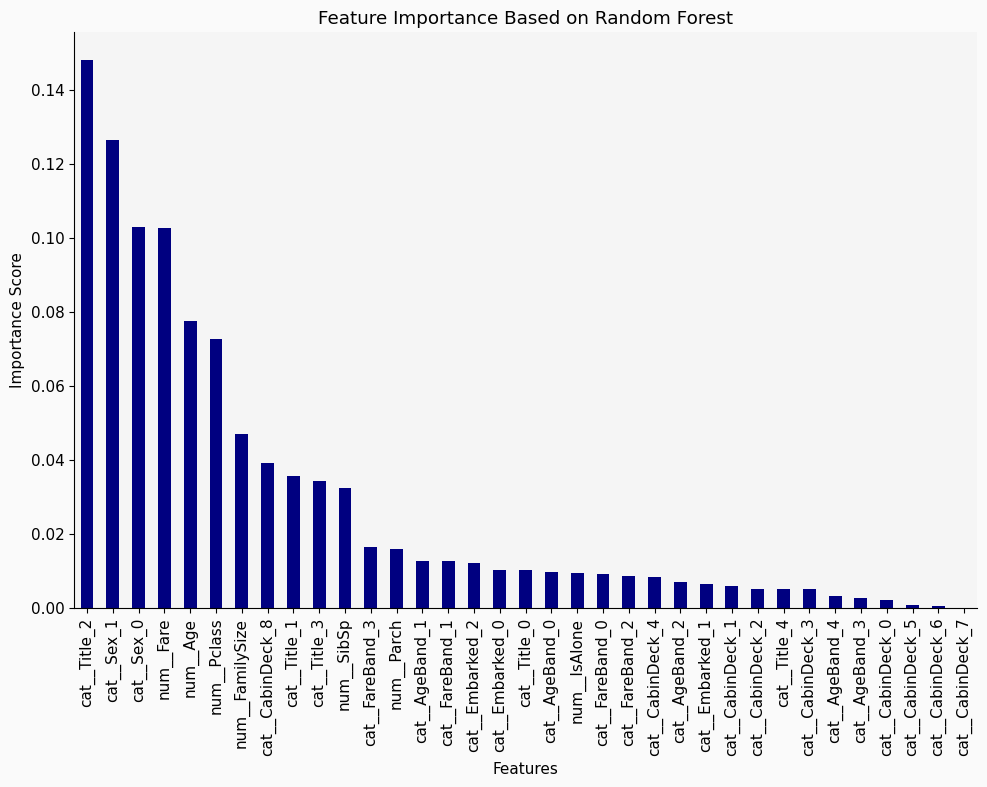

In [ ]:
feature_names = preprocessor.get_feature_names_out()

importances = pd.Series(rf.feature_importances_, index=feature_names)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances_sorted.plot(kind='bar', color='navy')
plt.title('Feature Importance Based on Random Forest')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

### 6.2 Gradient Boosting
Train a Gradient Boosting model as a comparison against Random Forest. Gradient Boosting is an algorithm that can capture non-linear relationships in the data

In [43]:
gb = GradientBoostingClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, random_state=42
)

gb.fit(X_train_processed, y)

gb_train_pred = gb.predict(X_train_processed)
gb_train_proba = gb.predict_proba(X_train_processed)

train_accuracy = accuracy_score(y, gb_train_pred)
train_loss = log_loss(y, gb_train_proba)

print(f"Gradient Boosting Training Accuracy: {train_accuracy:.4f}")
print(f"Gradient Boosting Training Log Loss: {train_loss:.4f}")

Gradient Boosting Training Accuracy: 0.9405
Gradient Boosting Training Log Loss: 0.2043


Feature Importance Analysis

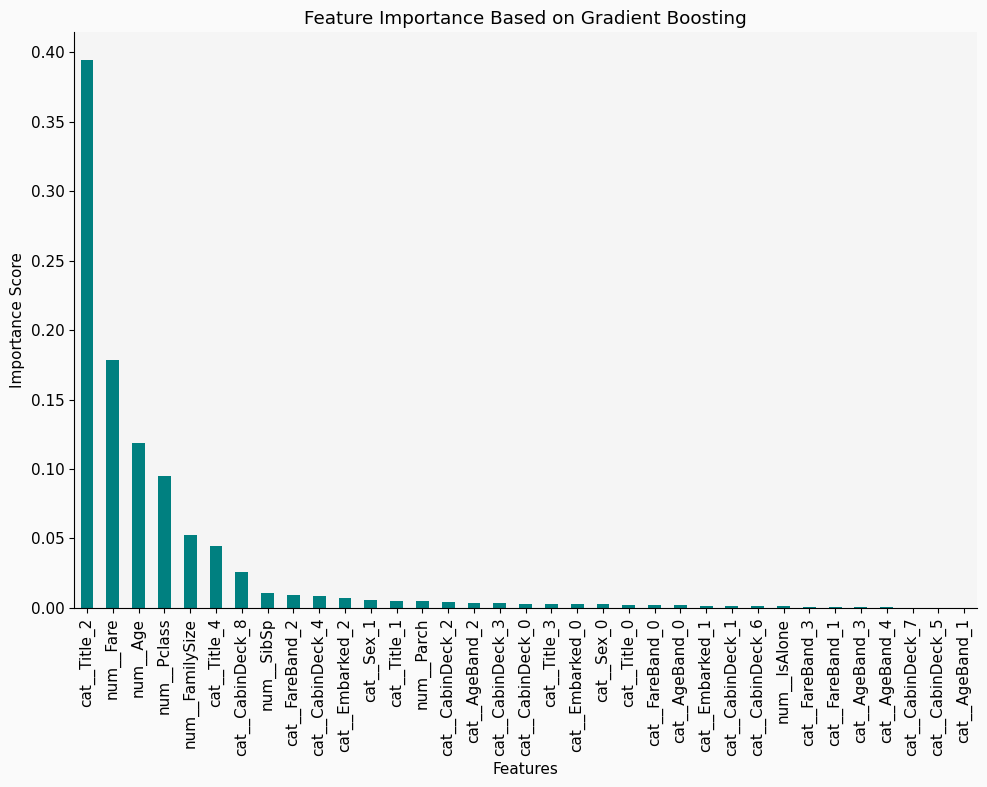

In [44]:
feature_names = preprocessor.get_feature_names_out()

importances = pd.Series(gb.feature_importances_, index=feature_names)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances_sorted.plot(kind='bar', color='teal')
plt.title('Feature Importance Based on Gradient Boosting')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

### 6.3 XGBoost
Train an XGBoost model as a comparison against Linear Regression. XGBoost is a gradient boosting algorithm that can capture non-linear relationships in the data

In [45]:
xgb = XGBClassifier(
    n_estimators=200, max_depth=4,
    learning_rate=0.05, use_label_encoder=False,
    eval_metric='logloss', random_state=42
)

xgb.fit(X_train_processed, y)

xgb_train_pred = xgb.predict(X_train_processed)
xgb_train_proba = xgb.predict_proba(X_train_processed)

train_accuracy = accuracy_score(y, xgb_train_pred)
train_loss = log_loss(y, xgb_train_proba)

print(f"XGBoost Training Accuracy: {train_accuracy:.4f}")
print(f"XGBoost Training Log Loss: {train_loss:.4f}")

XGBoost Training Accuracy: 0.9057
XGBoost Training Log Loss: 0.2674


Feature Importance Analysis

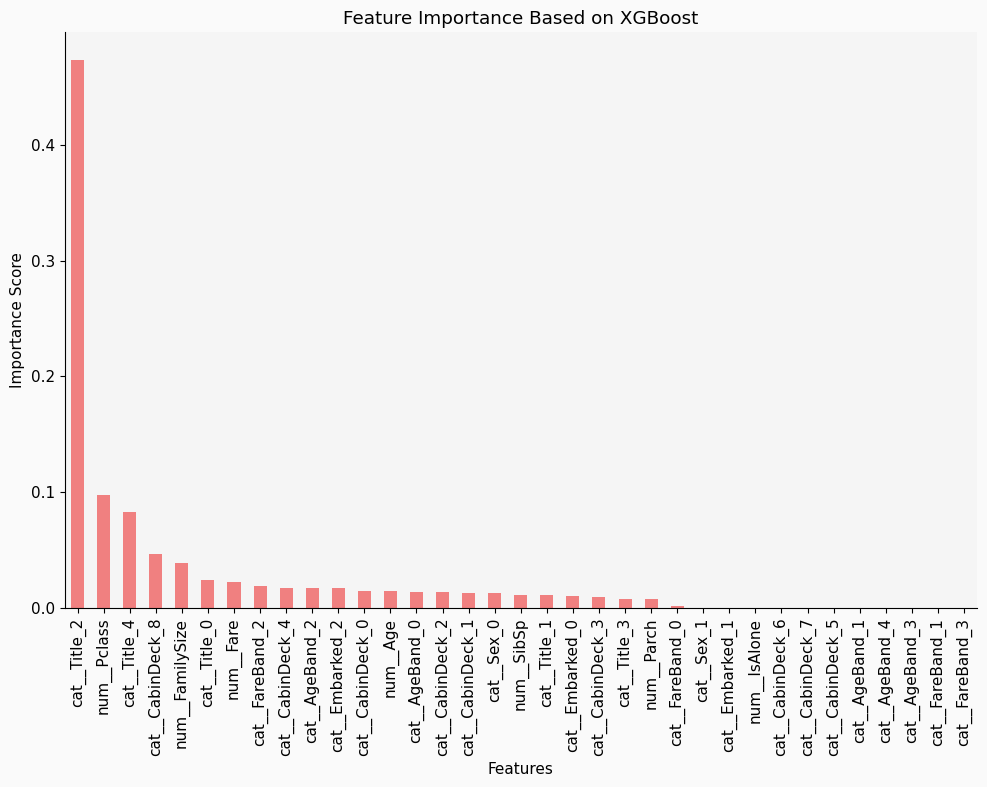

In [49]:
feature_names = preprocessor.get_feature_names_out()

importances = pd.Series(xgb.feature_importances_, index=feature_names)
importances_sorted = importances.sort_values(ascending=False)

plt.figure(figsize=(10, 8))
importances_sorted.plot(kind='bar', color='lightcoral')
plt.title('Feature Importance Based on XGBoost')
plt.xlabel('Features')
plt.ylabel('Importance Score')
plt.tight_layout()
plt.show()

### 6.4 Model Performance Comparison
Calculate and compare model accuracy using cross validation

In [50]:
models = {'Random Forest': rf, 'Gradient Boosting': gb, 'XGBoost': xgb}

results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f"{name:<25} {scores.mean():.4f} ± {scores.std():.4f}")

Random Forest             0.8350 ± 0.0100
Gradient Boosting         0.8294 ± 0.0182
XGBoost                   0.8350 ± 0.0249


## 7. Voting Ensemble
Soft Voting/Majority Rule classifier for unfitted estimators. Output a robust final prediction

In [ ]:
ensemble = VotingClassifier(
    estimators=[('rf', rf), ('gb', gb), ('xgb', xgb)],
    voting='soft'
)

ensemble_scores = cross_val_score(ensemble, X_train_processed, y, cv=cv, scoring='accuracy')
print(f"{'Voting Ensemble':<25} {ensemble_scores.mean():.4f} ± {ensemble_scores.std():.4f}")

ensemble.fit(X_train_processed, y)

predictions = ensemble.predict(X_test_processed)

output = pd.DataFrame({
    'PassengerId': test.PassengerId, 
    'Survived': predictions
})

output.to_csv('kaggle/submission.csv', index=False)
print("Your submission was successfully saved!")

Voting Ensemble           0.8440 ± 0.0188
Your submission was successfully saved!


## 8. Save Pipeline Artifacts
Save models and metrics as .pkl file

In [58]:
os.makedirs('../models', exist_ok=True)

ensemble.fit(X, y)
train_acc = accuracy_score(y, ensemble.predict(X))

metrics = {
    'ensemble': {
        'cv_accuracy': round(ensemble_scores.mean(), 4),
        'cv_std':      round(ensemble_scores.std(), 4),
        'train_accuracy': round(train_acc, 4),
    },
    'individual': {
        name: {
            'cv_accuracy': round(scores.mean(), 4),
            'cv_std':      round(scores.std(), 4),
        }
        for name, scores in results.items()
    }
}

with open('../models/model.pkl', 'wb') as f:
    pickle.dump(ensemble, f)

with open('../models/feature_names.pkl', 'wb') as f:
    pickle.dump(features, f)

with open('../models/metrics.pkl', 'wb') as f:
    pickle.dump(metrics, f)

print("Artifacts saved:")
for k, v in metrics.items():
    print(f"  {k}: {v}")

Artifacts saved:
  ensemble: {'cv_accuracy': np.float64(0.844), 'cv_std': np.float64(0.0188), 'train_accuracy': 0.9248}
  individual: {'Random Forest': {'cv_accuracy': np.float64(0.835), 'cv_std': np.float64(0.01)}, 'Gradient Boosting': {'cv_accuracy': np.float64(0.8294), 'cv_std': np.float64(0.0182)}, 'XGBoost': {'cv_accuracy': np.float64(0.835), 'cv_std': np.float64(0.0249)}}


In [55]:
print('Pipeline Artifacts\n')
for file in sorted(os.listdir('../models')):
    size = os.path.getsize(f'../models/{file}')
    print(f'{file:30s} {size / 1024:.1f} KB')
print('\n All artifacts saved successfully')

Pipeline Artifacts

feature_names.pkl              0.1 KB
metrics.pkl                    0.4 KB
model.pkl                      13859.8 KB

 All artifacts saved successfully


## 9. Conclusion

### Summary
This notebook built and evaluated 3 prediction models — Random Forest, Gradient Boosting and XGBoost — on a dataset of 831 passengers records across 13 features.

### Key Findings
- Parch was the strongest predictor of Sibsp with a correlation of 0.41
- Feature engineering improved model performance by capturing title, ageband and fareband type
- Voting ensemble classifier output a mean accuracy score of ~83% based on the best performance of 3 models

### Next Steps
- Export final model to model.py for production use
- Explore hyperparameter tuning for XGBoost
- Investigate additional features such as performance scores or tenure

# Thanks For Reading!